# Naive Bayes from Scratch — Play Tennis Dataset

**Naive Bayes** is a simple probabilistic classifier based on **Bayes' Theorem**. It assumes that all input features are independent of each other given the class — this is the "naive" assumption, and it rarely holds perfectly in real life, but the algorithm still works surprisingly well.

The core idea: for a new input, Naive Bayes calculates the probability of **each possible class** given the input's features, and then predicts the class with the **highest probability**.

The animation below shows this idea using our actual dataset: we start with the **prior probability** of each class, then multiply in the **likelihood** of each feature value, and end up with a final prediction.

![Naive Bayes Animation](../GIF/naive_bayes.gif)


## 1. Load and Explore the Data

We start by loading the dataset and taking a quick look at its structure.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data_SET/play_tennis.csv")
df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


**About this dataset:**
- **Input features:** `outlook`, `temp`, `humidity`, `wind` — all categorical.
- **Target variable:** `play` — whether tennis was played on that day.
- **Type of problem:** binary classification.
- **Classes:** `Yes` and `No`.
- The `day` column is just a row identifier and is not used as a feature.


## 2. Select Features and Target

All feature columns are categorical (text values like "Sunny" or "Hot"), so we use them as-is — no numeric encoding or scaling is needed for Naive Bayes with frequency counts.

In [4]:
features = ["outlook", "temp", "humidity", "wind"]
target = "play"

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("Classes:", sorted(y.unique()))

Features: ['outlook', 'temp', 'humidity', 'wind']
Target: play
Classes: ['No', 'Yes']


## 3. Train/Test Split (Manual)

We shuffle the row indices with NumPy and split the data ourselves (no `train_test_split` from scikit-learn), using roughly an 80/20 split.

This dataset only has 14 rows, so a train/test split here is mainly for illustration — with so little data, results on the test set won't be statistically meaningful, but it's useful for learning how the workflow works.

In [5]:
np.random.seed(42)

indices = np.arange(len(df))
np.random.shuffle(indices)

split_point = int(len(df) * 0.8)
train_idx, test_idx = indices[:split_point], indices[split_point:]

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 11
Test size: 3


## 4. The Math Behind Naive Bayes

**Prior probability — P(class):**
How often each class appears in the training data, regardless of the features.

**Likelihood — P(feature | class):**
How often a specific feature value shows up within a given class. For example, P(outlook=Sunny | play=Yes) is the fraction of "Yes" days where the outlook was Sunny.

**Bayes' Theorem (simplified):**

```
P(class | features) ∝ P(class) * P(feature_1 | class) * P(feature_2 | class) * ...
```

We drop the normalizing denominator from the full theorem since it's the same for every class — we only need the *relative* size of each class's score to pick the largest one.

**The "naive" assumption:** we treat all features as independent given the class, which lets us simply multiply their individual likelihoods together instead of modeling how they interact.

**Laplace smoothing:** if a feature value never appears with a class in the training data, its likelihood would be exactly 0, which would zero out the whole prediction. To avoid this, we add a small smoothing value (1) to every count so no probability is ever exactly zero.


## 5. Naive Bayes From Scratch

We implement three simple steps:
1. Compute the **prior** probability of each class.
2. Compute the **likelihood** of each feature value within each class (with Laplace smoothing).
3. **Predict** by multiplying the prior and likelihoods together for each class, and picking the largest result.

In [6]:
def compute_priors(train_df, target):
    """P(class) for every class in the training data."""
    counts = train_df[target].value_counts()
    total = len(train_df)
    return (counts / total).to_dict()

priors = compute_priors(train_df, target)
priors

{'Yes': 0.5454545454545454, 'No': 0.45454545454545453}

In [7]:
def compute_likelihoods(train_df, features, target, alpha=1):
    """
    P(feature_value | class) for every feature, value, and class,
    using frequency counts with Laplace smoothing.

    Returns a nested dict: likelihoods[feature][class][value] = probability
    """
    likelihoods = {}
    classes = train_df[target].unique()

    for feature in features:
        likelihoods[feature] = {}
        possible_values = train_df[feature].unique()
        k = len(possible_values)  # number of possible values for this feature

        for c in classes:
            subset = train_df[train_df[target] == c]
            class_total = len(subset)
            likelihoods[feature][c] = {}

            for value in possible_values:
                count = (subset[feature] == value).sum()
                # Laplace smoothing: add alpha to the count and alpha*k to the total
                prob = (count + alpha) / (class_total + alpha * k)
                likelihoods[feature][c][value] = prob

    return likelihoods

likelihoods = compute_likelihoods(train_df, features, target)
likelihoods["outlook"]

{'Yes': {'Rain': np.float64(0.3333333333333333),
  'Overcast': np.float64(0.4444444444444444),
  'Sunny': np.float64(0.2222222222222222)},
 'No': {'Rain': np.float64(0.375),
  'Overcast': np.float64(0.125),
  'Sunny': np.float64(0.5)}}

In [8]:
def predict_one(sample, priors, likelihoods, features, alpha=1):
    """
    Predict the class for a single sample (a dict like {"outlook": "Sunny", ...}).
    Returns the predicted class and a dict of the raw scores for each class.
    """
    scores = {}

    for c in priors:
        score = priors[c]  # start with the prior probability

        for feature in features:
            value = sample[feature]
            feature_likelihoods = likelihoods[feature][c]

            if value in feature_likelihoods:
                score *= feature_likelihoods[value]
            else:
                # Unseen value during training: fall back to a smoothed default
                score *= alpha / (alpha * len(feature_likelihoods))

        scores[c] = score

    predicted_class = max(scores, key=scores.get)
    return predicted_class, scores

def predict(df_to_predict, priors, likelihoods, features, alpha=1):
    """Predict the class for every row in a DataFrame."""
    predictions = []
    for _, row in df_to_predict.iterrows():
        sample = row[features].to_dict()
        pred_class, _ = predict_one(sample, priors, likelihoods, features, alpha)
        predictions.append(pred_class)
    return predictions

## 6. Making Predictions

For each test sample, we multiply the class prior by the likelihood of every observed feature value, for every class. Whichever class ends up with the highest combined score is our prediction.

In [9]:
test_predictions = predict(test_df, priors, likelihoods, features)

results = test_df[features + [target]].copy()
results["predicted"] = test_predictions
results

,outlook,temp,humidity,wind,play,predicted
0,Sunny,Mild,Normal,Strong,Yes,No
1,Rain,Mild,High,Weak,Yes,No
2,Overcast,Cool,Normal,Strong,Yes,Yes


## 7. Model Evaluation

We calculate accuracy manually, plus a simple confusion matrix.

In [10]:
actual = results[target].values
predicted = results["predicted"].values

correct = (actual == predicted).sum()
accuracy = correct / len(actual)

print(f"Correct predictions: {correct}/{len(actual)}")
print(f"Accuracy: {accuracy:.2f}")

Correct predictions: 1/3
Accuracy: 0.33


In [11]:
# Simple confusion matrix for the "Yes" class
tp = np.sum((actual == "Yes") & (predicted == "Yes"))
tn = np.sum((actual == "No") & (predicted == "No"))
fp = np.sum((actual == "No") & (predicted == "Yes"))
fn = np.sum((actual == "Yes") & (predicted == "No"))

print("Confusion Matrix (positive class = 'Yes')")
print(f"True Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

Confusion Matrix (positive class = 'Yes')
True Positives:  1
True Negatives:  0
False Positives: 0
False Negatives: 2


## 8. Visualization

Since our features are categorical, there's no numeric decision boundary to plot. Instead, we show a bar chart comparing the predicted probability of each class for a couple of example inputs — this makes it easy to see how confidently Naive Bayes chooses between "Yes" and "No".

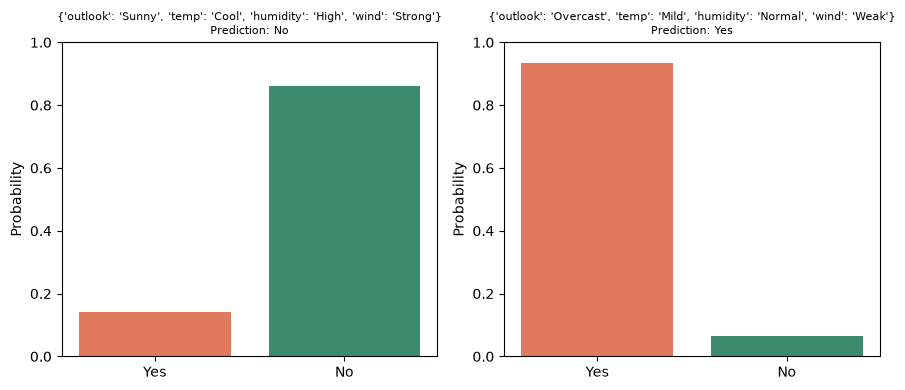

In [12]:
examples = [
    {"outlook": "Sunny", "temp": "Cool", "humidity": "High", "wind": "Strong"},
    {"outlook": "Overcast", "temp": "Mild", "humidity": "Normal", "wind": "Weak"},
]

fig, axes = plt.subplots(1, len(examples), figsize=(9, 4))

for ax, example in zip(axes, examples):
    pred_class, scores = predict_one(example, priors, likelihoods, features)

    # normalize scores into probabilities that sum to 1, just for the chart
    total = sum(scores.values())
    probs = {c: s / total for c, s in scores.items()}

    ax.bar(probs.keys(), probs.values(), color=["#e07a5f", "#3d8a6e"])
    ax.set_ylim(0, 1)
    ax.set_title(f"{example}\nPrediction: {pred_class}", fontsize=8)
    ax.set_ylabel("Probability")

plt.tight_layout()
plt.show()

## 9. Conclusion

- **Naive Bayes** is a probabilistic classifier built on **Bayes' Theorem**.
- It combines the **prior probability** of each class with the **likelihood** of the observed feature values to score every class, and predicts the class with the highest score.
- It's called "naive" because it assumes all features are **independent** given the class, which simplifies the math a lot even though it's rarely 100% true in practice.
- **Laplace smoothing** keeps the model from breaking when it encounters a feature value it never saw during training.
- Despite its simplicity, Naive Bayes is fast, easy to understand, and works well as a baseline for many classification problems.
